In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import healpy as hp

In [2]:
NSIDE = 4096
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 4096 is 0.014 deg


In [3]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

201326592


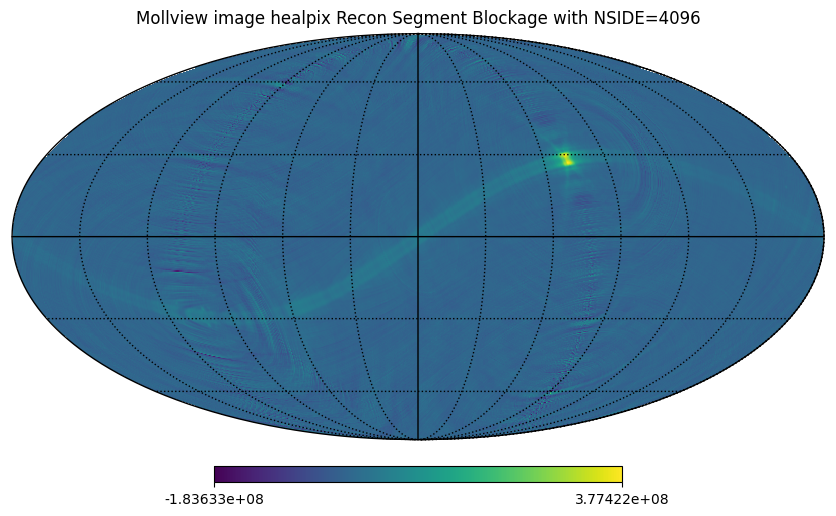

In [4]:
recon_seg_block_image = np.loadtxt("./out10M_online/C1day10M.txt")

hp.mollview(recon_seg_block_image, nest=True, title="Mollview image healpix Recon Segment Blockage with NSIDE=4096")
hp.graticule()  # 添加经纬线
plt.show()

# 对比可见度

In [9]:
import math

def read_complex_file(filename):
    """读取文件，返回复数列表"""
    complexes = []
    with open(filename, 'r') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                real = float(parts[0])
                imag = float(parts[1])
                complexes.append((line_num, real, imag))
    return complexes

def compare_complex_files(file1, file2, tolerance=1e-9):
    """比较两个复数文件，找出第一个不匹配的行"""
    
    # 读取两个文件
    data1 = read_complex_file(file1)
    data2 = read_complex_file(file2)
    
    print(f"文件1: {file1} - 共 {len(data1)} 行")
    print(f"文件2: {file2} - 共 {len(data2)} 行")
    print("-" * 60)
    
    # 检查行数是否相同
    if len(data1) != len(data2):
        print(f"⚠️  警告：两个文件的行数不同！")
        print(f"   文件1有 {len(data1)} 行，文件2有 {len(data2)} 行")
    
    # 逐行比较
    min_lines = min(len(data1), len(data2))
    
    for i in range(min_lines):
        line_num1, real1, imag1 = data1[i]
        line_num2, real2, imag2 = data2[i]
        
        # 比较实部
        real_match = math.isclose(real1, real2, rel_tol=tolerance, abs_tol=tolerance)
        # 比较虚部
        imag_match = math.isclose(imag1, imag2, rel_tol=tolerance, abs_tol=tolerance)
        
        if not (real_match and imag_match):
            print(f"❌ 第 {line_num1} 行开始不相等：")
            print(f"   文件1: {real1:.6e} {imag1:.6e}")
            print(f"   文件2: {real2:.6e} {imag2:.6e}")
            
            if not real_match:
                diff_real = abs(real1 - real2)
                print(f"   实部差异: {diff_real:.6e}")
            if not imag_match:
                diff_imag = abs(imag1 - imag2)
                print(f"   虚部差异: {diff_imag:.6e}")
            return line_num1
    
    print("✅ 所有行都相等（在容差范围内）")
    
    # 如果一个文件比另一个长
    if len(data1) > len(data2):
        print(f"⚠️  但文件1比文件2多 {len(data1) - len(data2)} 行")
        return len(data2) + 1
    elif len(data2) > len(data1):
        print(f"⚠️  但文件2比文件1多 {len(data2) - len(data1)} 行")
        return len(data1) + 1
    
    return None


In [10]:
# 请修改为你的实际文件路径
file1_path = "viss_recon_seg/out10M_recon_seg_viss_conj_viss_seg/Viss1day10M.txt"  
file2_path = "out10M_online/Viss1day10M.txt"

# 运行比较
result = compare_complex_files(file1_path, file2_path)

if result:
    print(f"\n📍 第一个不匹配的行号: {result}")
else:
    print("\n📍 两个文件完全相同")

文件1: viss_recon_seg/out10M_recon_seg_viss_conj_viss_seg/Viss1day10M.txt - 共 3909360 行
文件2: out10M_online/Viss1day10M.txt - 共 3909360 行
------------------------------------------------------------
❌ 第 1 行开始不相等：
   文件1: 6.061950e+11 4.984310e+10
   文件2: 6.021060e+11 5.015800e+10
   实部差异: 4.089000e+09
   虚部差异: 3.149000e+08

📍 第一个不匹配的行号: 1


# 对比反演天图结果

In [11]:
import math

def read_single_column_file(filename, skip_first=False):
    """读取单列文件，返回数值列表"""
    values = []
    with open(filename, 'r') as f:
        lines = f.readlines()
        # 根据参数决定是否跳过第一行
        start_idx = 1 if skip_first else 0
        for line in lines[start_idx:]:
            line = line.strip()
            if not line:
                continue
            try:
                val = float(line)
                values.append(val)
            except ValueError:
                # 如果转换失败，可能是空行或注释，跳过
                continue
    return values

def compare_single_column_files(file1, file2, tolerance=1e-9, skip_first1=False, skip_first2=False):
    """比较两个单列文件是否相同"""
    
    # 读取两个文件
    data1 = read_single_column_file(file1, skip_first1)
    data2 = read_single_column_file(file2, skip_first2)
    
    print(f"文件1: {file1}")
    print(f"  - {'跳过' if skip_first1 else '包含'}第一行")
    print(f"  - 有效数据行数: {len(data1)}")
    print()
    print(f"文件2: {file2}")
    print(f"  - {'跳过' if skip_first2 else '包含'}第一行")
    print(f"  - 有效数据行数: {len(data2)}")
    print("-" * 60)
    
    # 检查行数是否相同
    if len(data1) != len(data2):
        print(f"❌ 行数不同！文件1有 {len(data1)} 行，文件2有 {len(data2)} 行")
        return False
    
    total_lines = len(data1)
    if total_lines == 0:
        print("⚠️  两个文件都为空")
        return True
    
    # 逐行比较
    first_diff_line = None
    diff_count = 0
    max_diff = 0.0
    
    for i in range(total_lines):
        val1 = data1[i]
        val2 = data2[i]
        
        if not math.isclose(val1, val2, rel_tol=tolerance, abs_tol=tolerance):
            diff_count += 1
            current_diff = abs(val1 - val2)
            max_diff = max(max_diff, current_diff)
            
            if first_diff_line is None:
                first_diff_line = i + 1  # 记录第一个不匹配的行号（1-based）
                print(f"❌ 第 {first_diff_line} 行开始不相等：")
                print(f"   文件1: {val1:.10e}")
                print(f"   文件2: {val2:.10e}")
                print(f"   差异:  {current_diff:.10e}")
                
                # 显示附近几行以便定位
                if i > 0:
                    print(f"   上一行({i}):")
                    print(f"      文件1: {data1[i-1]:.6e}")
                    print(f"      文件2: {data2[i-1]:.6e}")
    
    print("-" * 60)
    
    if first_diff_line is None:
        print(f"✅ 两个文件完全相同！共 {total_lines} 行数据")
        return True
    else:
        print(f"⚠️  比较结果：")
        print(f"   - 总行数: {total_lines}")
        print(f"   - 不匹配行数: {diff_count} ({diff_count/total_lines*100:.2f}%)")
        print(f"   - 第一个不匹配行: 第 {first_diff_line} 行")
        print(f"   - 最大差异值: {max_diff:.10e}")
        return False


In [12]:
file1_path = "viss_recon_seg/out10M_recon_seg_viss_conj_viss_seg/C1day10M.txt"  
file2_path = "out10M_online/C1day10M.txt"

# 参数设置
skip_first_line_file1 = False  # 文件1是否跳过第一行（如为表头则设为True）
skip_first_line_file2 = False  # 文件2是否跳过第一行（如为表头则设为True）
tolerance = 1e-9               # 浮点数比较容差

# 运行比较
result = compare_single_column_files(
    file1_path, 
    file2_path,
    tolerance=tolerance,
    skip_first1=skip_first_line_file1,
    skip_first2=skip_first_line_file2
)

print(f"\n📍 最终结果: {'相同' if result else '不同'}")

文件1: viss_recon_seg/out10M_recon_seg_viss_conj_viss_seg/C1day10M.txt
  - 包含第一行
  - 有效数据行数: 201326592

文件2: out10M_online/C1day10M.txt
  - 包含第一行
  - 有效数据行数: 201326592
------------------------------------------------------------
❌ 第 1 行开始不相等：
   文件1: -1.3566900000e+06
   文件2: 3.2217400000e+06
   差异:  4.5784300000e+06
------------------------------------------------------------
⚠️  比较结果：
   - 总行数: 201326592
   - 不匹配行数: 201322296 (100.00%)
   - 第一个不匹配行: 第 1 行
   - 最大差异值: 9.5164000000e+07

📍 最终结果: 不同


# 验证Viss前后共轭

In [7]:
import math

def read_complex_file_skip_first(filename):
    """读取文件，跳过第一行，返回复数列表 (real, imag)"""
    complexes = []
    with open(filename, 'r') as f:
        lines = f.readlines()
        # 跳过第一行，从第二行开始
        for line in lines:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                real = float(parts[0])
                imag = float(parts[1])
                complexes.append((real, imag))
    return complexes

def check_conjugate_pairs(data, tolerance=1e-9):
    """检查数据是否每56行一组，前28行与后28行互为共轭复数"""
    # 共轭复数定义：a+bi 和 a-bi（实部相等，虚部相反）
    
    total_lines = len(data)
    print(f"总数据行数: {total_lines}")
    
    # 计算有多少个完整的56行组
    num_groups = total_lines // 56
    remaining = total_lines % 56
    
    print(f"可分为 {num_groups} 个完整的56行组")
    if remaining > 0:
        print(f"剩余 {remaining} 行未组成完整的一组")
    print("-" * 60)
    
    all_passed = True
    
    for group_idx in range(num_groups):
        start_idx = group_idx * 56
        group_data = data[start_idx:start_idx + 56]
        
        first_half = group_data[:28]   # 前28行
        second_half = group_data[28:]  # 后28行
        
        group_passed = True
        
        for i in range(28):
            real1, imag1 = first_half[i]
            real2, imag2 = second_half[i]
            
            # 检查是否互为共轭：real2 ≈ real1 且 imag2 ≈ -imag1
            real_match = math.isclose(real2, real1, rel_tol=tolerance, abs_tol=tolerance)
            imag_conjugate = math.isclose(imag2, -imag1, rel_tol=tolerance, abs_tol=tolerance)
            
            if not (real_match and imag_conjugate):
                if group_passed:
                    print(f"\n❌ 第 {group_idx + 1} 组（文件第 {start_idx + 2}-{start_idx + 57} 行）验证失败：")
                    group_passed = False
                    all_passed = False
                
                print(f"   第 {i + 1} 对不匹配（组内位置 {i + 1} vs {i + 29}）：")
                print(f"   前一半:  {real1:.6e} {imag1:+.6e}i")
                print(f"   后一半:  {real2:.6e} {imag2:+.6e}i")
                print(f"   期望后一半(共轭): {real1:.6e} {-imag1:+.6e}i")
                
                if not real_match:
                    diff = abs(real2 - real1)
                    print(f"   ⚠️  实部不匹配，差异: {diff:.6e}")
                if not imag_conjugate:
                    diff = abs(imag2 - (-imag1))
                    print(f"   ⚠️  虚部不匹配，差异: {diff:.6e}")
        
    
    print("-" * 60)
    if all_passed:
        print("🎉 所有组验证通过！前一半和后一半确实互为共轭复数")
        print("   (即：实部相等，虚部互为相反数)")
    else:
        print("⚠️  存在验证失败的组")
    
    return all_passed


In [8]:
# 请修改为你的实际文件路径
file_path = "out10M_online/Viss1day10M.txt"  # 替换为你的文件路径

# 读取数据（自动跳过第一行）
data = read_complex_file_skip_first(file_path)

# 验证共轭关系
check_conjugate_pairs(data)

总数据行数: 3909360
可分为 69810 个完整的56行组
------------------------------------------------------------
------------------------------------------------------------
🎉 所有组验证通过！前一半和后一半确实互为共轭复数
   (即：实部相等，虚部互为相反数)


True

# 验证基线前后相反

In [5]:
import math

def read_complex_file_skip_first(filename):
    complexes = []
    with open(filename, 'r') as f:
        lines = f.readlines()
        for line in lines:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                real = float(parts[0])
                imag = float(parts[1])
                complexes.append((real, imag))
    return complexes

def check_opposite_pairs(data, tolerance=1e-9):
    """检查数据是否每56行一组，前28行与后28行互为相反数"""
    
    total_lines = len(data)
    print(f"总数据行数: {total_lines}")
    
    # 计算有多少个完整的56行组
    num_groups = total_lines // 56
    remaining = total_lines % 56
    
    print(f"可分为 {num_groups} 个完整的56行组")
    if remaining > 0:
        print(f"剩余 {remaining} 行未组成完整的一组")
    print("-" * 60)
    
    all_passed = True
    
    for group_idx in range(num_groups):
        start_idx = group_idx * 56
        group_data = data[start_idx:start_idx + 56]
        
        first_half = group_data[:28]   # 前28行
        second_half = group_data[28:]  # 后28行
        
        group_passed = True
        
        for i in range(28):
            real1, imag1 = first_half[i]
            real2, imag2 = second_half[i]
            
            # 检查是否互为相反数：real2 ≈ -real1 且 imag2 ≈ -imag1
            real_opposite = math.isclose(real2, -real1, rel_tol=tolerance, abs_tol=tolerance)
            imag_opposite = math.isclose(imag2, -imag1, rel_tol=tolerance, abs_tol=tolerance)
            
            if not (real_opposite and imag_opposite):
                if group_passed:
                    print(f"\n❌ 第 {group_idx + 1} 组（文件第 {start_idx + 2}-{start_idx + 57} 行）验证失败：")
                    group_passed = False
                    all_passed = False
                
                print(f"   第 {i + 1} 对不匹配（组内位置 {i + 1} vs {i + 29}）：")
                print(f"   前一半:  {real1:.6e} {imag1:.6e}")
                print(f"   后一半:  {real2:.6e} {imag2:.6e}")
                print(f"   期望后一半: {-real1:.6e} {-imag1:.6e}")
                
                if not real_opposite:
                    print(f"   实部差异: {abs(real2 - (-real1)):.6e}")
                if not imag_opposite:
                    print(f"   虚部差异: {abs(imag2 - (-imag1)):.6e}")
        
        # if group_passed:
        #     print(f"✅ 第 {group_idx + 1} 组验证通过（文件第 {start_idx + 2}-{start_idx + 57} 行）")
    
    print("-" * 60)
    if all_passed:
        print("🎉 所有组验证通过！前一半和后一半确实互为相反数")
    else:
        print("⚠️  存在验证失败的组")
    
    return all_passed

In [6]:

# 请修改为你的实际文件路径
file_path = "out10M_online/uvw1day10M.txt"  

# 读取数据
data = read_complex_file_skip_first(file_path)

# 验证相反数关系
check_opposite_pairs(data)

总数据行数: 3909360
可分为 69810 个完整的56行组
------------------------------------------------------------
------------------------------------------------------------
🎉 所有组验证通过！前一半和后一半确实互为相反数


True

# 验证基线一致

In [13]:
def iter_three_col_file(filename, skip_first=False):
    """按行读取三列浮点数文件，返回 (文件行号, x, y, z)。跳过空行。"""
    with open(filename, "r") as f:
        if skip_first:
            next(f, None)  # 跳过第一行（如表头）
            start_line = 2
        else:
            start_line = 1

        for line_no, line in enumerate(f, start=start_line):
            s = line.strip()
            if not s:
                continue
            parts = s.split()
            if len(parts) < 3:
                raise ValueError(f"{filename} 第 {line_no} 行列数不足3列: {s}")
            yield line_no, float(parts[0]), float(parts[1]), float(parts[2])


def compare_uvw_files(file1, file2, tolerance=1e-9, skip_first1=False, skip_first2=False):
    """比较两个uvw三列txt文件是否相等（支持浮点容差）。"""
    it1 = iter_three_col_file(file1, skip_first=skip_first1)
    it2 = iter_three_col_file(file2, skip_first=skip_first2)

    valid_row = 0
    while True:
        try:
            r1 = next(it1)
            end1 = False
        except StopIteration:
            end1 = True

        try:
            r2 = next(it2)
            end2 = False
        except StopIteration:
            end2 = True

        if end1 and end2:
            print(f"✅ 两个文件相等，共比较 {valid_row} 行有效数据")
            return True

        if end1 != end2:
            print("❌ 两个文件有效数据行数不同")
            return False

        valid_row += 1
        ln1, a1, b1, c1 = r1
        ln2, a2, b2, c2 = r2

        ok_a = math.isclose(a1, a2, rel_tol=tolerance, abs_tol=tolerance)
        ok_b = math.isclose(b1, b2, rel_tol=tolerance, abs_tol=tolerance)
        ok_c = math.isclose(c1, c2, rel_tol=tolerance, abs_tol=tolerance)

        if not (ok_a and ok_b and ok_c):
            print(f"❌ 第一个不匹配出现在有效数据第 {valid_row} 行")
            print(f"   文件1 行号 {ln1}: {a1:.10e} {b1:.10e} {c1:.10e}")
            print(f"   文件2 行号 {ln2}: {a2:.10e} {b2:.10e} {c2:.10e}")
            print(f"   差异: {abs(a1-a2):.10e}, {abs(b1-b2):.10e}, {abs(c1-c2):.10e}")
            return False


In [14]:
uvw_file1 = "earth_10Mhz/uvw1day10M.txt"
uvw_file2 = "out10M_online/uvw1day10M.txt"

is_equal = compare_uvw_files(
    uvw_file1,
    uvw_file2,
    tolerance=1e-9,
    skip_first1=False,
    skip_first2=False
)

print(f"\n最终结果: {'相等' if is_equal else '不相等'}")

❌ 第一个不匹配出现在有效数据第 1 行
   文件1 行号 1: -0.0000000000e+00 -3.7238202095e+00 -2.1499476433e+00
   文件2 行号 1: -0.0000000000e+00 -3.7238200000e+00 -2.1499500000e+00
   差异: 0.0000000000e+00, 2.0950317392e-07, 2.3567199712e-06

最终结果: 不相等
